# INF264 - Project 2

## Part 1 - Automatic Malware Detection
I will be training three different types of classifiers: a decision tree, a multilayer perceptron, and a support vector machine.

I start by importing the dataset and splitting into X and y.

In [1]:
import numpy as np

dataset = np.load("dataset.npz")
X, y = dataset["X"], dataset["y"]

Let us start by looking at how many of each class we are actually working with.

In [2]:
classes, counts = np.unique(y, return_counts=True)
for c, n in zip(classes, counts):
    print(f"Class {c} has {n} samples.")

Class 0 has 755 samples.
Class 1 has 2305 samples.
Class 2 has 911 samples.
Class 3 has 721 samples.
Class 4 has 239 samples.
Class 5 has 1999 samples.
Class 6 has 4613 samples.
Class 7 has 2248 samples.
Class 8 has 771 samples.
Class 9 has 1001 samples.


A few thoughts:  
    - Class 0 has quite few samples for being the only "non-virus" class.  
    - Class 4 has very few samples compared to the other classes. The model will be bad at this one.  
    - Class 6 dominates, it has more samples than the second and third biggest samples combined.  
    - Conclusion, classes are not balanced.

Let us take a look at what the data actually looks like. I will plot one image from each of the 10 classes.

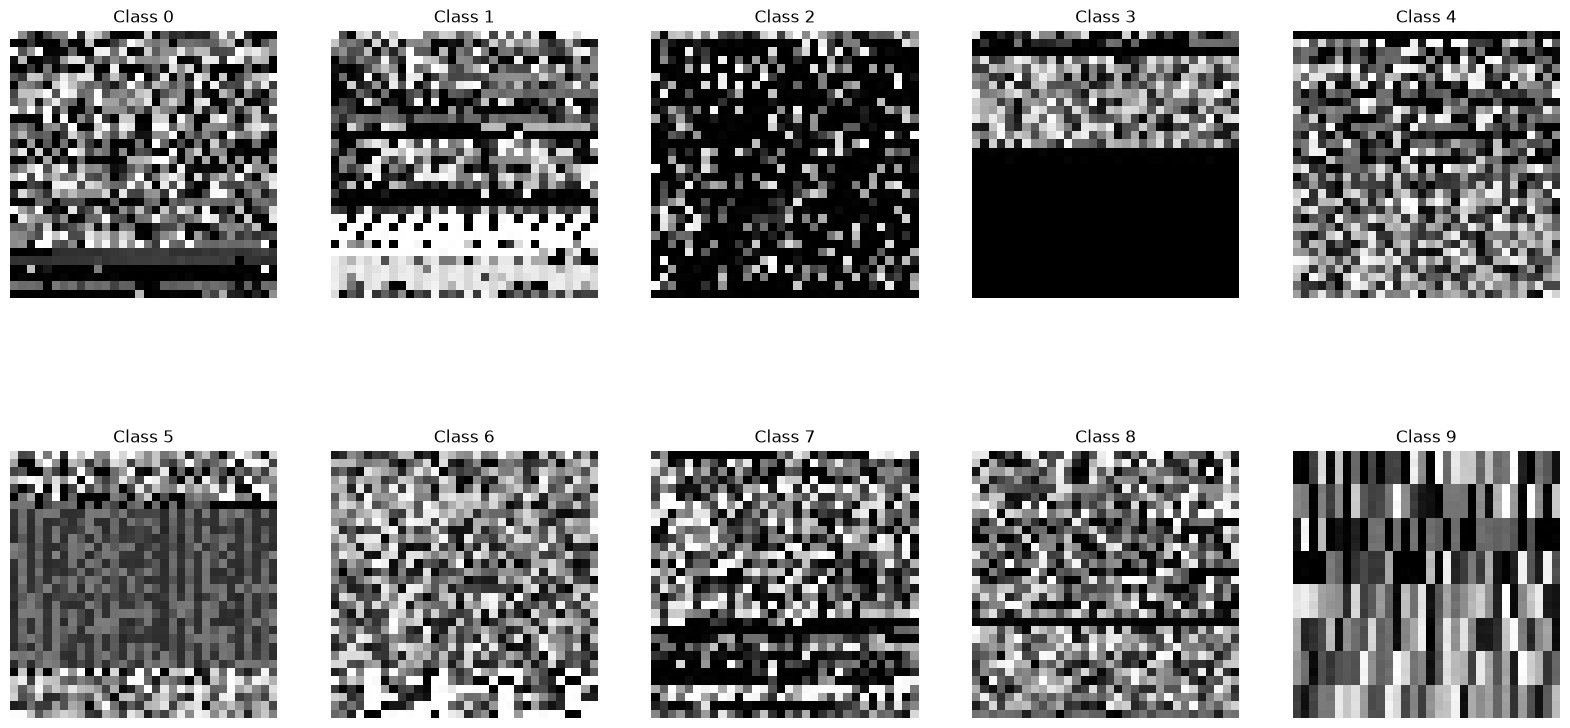

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))
axs = axs.flatten()

for i in range(10):
    idx = np.where(y==i)[0][0]

    axs[i].imshow(X[idx].reshape(32,32), vmin=0, vmax=255, cmap="gray")
    axs[i].set_title(f"Class {i}")
    axs[i].axis("off")

plt.show()

I will look for duplicates in the dataset using np.unique. This allows me to return an array of all the indices of the first instance of a sample. I can use this to construct a new deduped version of the dataset.

In [4]:
_, indices = np.unique(X, return_index=True, axis=0)
print(f"We have {len(indices)} unique samples in our data.")

We have 10871 unique samples in our data.


I created new versions of X and y which do not contain duplicates.

In [5]:
X_deduped = X[indices]
y_deduped = y[indices]

Let us also look at how many of each label we have after removing duplicates.

In [6]:
classes, counts = np.unique(y_deduped, return_counts=True)

for c, n in zip(classes, counts):
    print(f"Class {c} has {n} samples.")

Class 0 has 754 samples.
Class 1 has 320 samples.
Class 2 has 830 samples.
Class 3 has 687 samples.
Class 4 has 3 samples.
Class 5 has 1646 samples.
Class 6 has 3671 samples.
Class 7 has 1864 samples.
Class 8 has 589 samples.
Class 9 has 507 samples.


After removing duplicates, class 4 is useless. The models I train will be useless at predicting it. It will only act as noise in my training. The cleanest solution is to just remove it from the dataset completely and say that our models are not meant for detecting class 4.

In [7]:
X_deduped_trimmed = X_deduped[y_deduped != 4]
y_deduped_trimmed = y_deduped[y_deduped != 4]

classes = np.unique(y_deduped_trimmed)
print(f"We now have classes: {classes}.")

We now have classes: [0 1 2 3 5 6 7 8 9].


I split the data into a training set and a testing set. I set the size of the test set to 0.15, which is ~1631 samples. I also set a seed, 67, so that all my results are reproducible.

In [8]:
from sklearn.model_selection import train_test_split

seed = 67
X_train, X_test, y_train, y_test = train_test_split(X_deduped_trimmed, y_deduped_trimmed, test_size=0.15, random_state=seed, stratify=y_deduped_trimmed)
print(f"The training set has {len(y_train)} samples.")
print(f"The testing set has {len(y_test)} samples.")

The training set has 9237 samples.
The testing set has 1631 samples.


To measure the performance of my model I will use macro-F1-score. This gives me the mean F1-score for all classes. I will be doing grid search cross validation to find the best model in each model family. I use StratifiedKFold with n_splits=3. This means that each fold in the cross validation will have the same share of each class.  

(!) SHOULD I CHANGE TO 5 CV FOLDS FOR THE FINAL VERSION?

In [9]:
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold

def macro_f1(y_true, y_pred):
    return f1_score(y_true=y_true, y_pred=y_pred, average="macro")

scorer = make_scorer(macro_f1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

### Classifier 1 - Decision tree

I do grid search to select a decision tree model. I decided to try different values for criterion, max_depth, min_samples_leaf and ccp_alpha.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=seed, class_weight="balanced")

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 4, 8, 16, None],
    "min_samples_leaf": [1, 3, 5],
    "ccp_alpha": [0, 0.0005, 0.001, 0.005]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=2
)

# Moving all training until all models are defined
# grid_search_dt.fit(X_train, y_train)

### Classifier 2 - Multilayer perceptron

For MLP I decided to use MinMaxScaler to scale the data from [0, 255] to [0, 1]. This prevents values from exploding later in the network. I decided to try different values for hidden_layer_sizes, alpha and learning_rate_init.

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

pipe_mlp = Pipeline([
    ("scaler", MinMaxScaler()),
    ("mlp", MLPClassifier(random_state=seed, max_iter=1000))
])

param_grid_mlp = {
    "mlp__hidden_layer_sizes": [(256,), (138,), (128, 64,)],
    "mlp__alpha": [0.001, 0.01, 0.1],
    "mlp__learning_rate_init": [0.001, 0.01],
    "mlp__early_stopping": [True, False] # (!) Check if this should be kept
}

grid_search_mlp = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid_mlp,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=2
)

# grid_search_mlp.fit(X_train, y_train)

### Classifier 3 - Support vector classifier

In [12]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipe_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=seed)),
    ("svc", SVC(kernel="rbf", class_weight="balanced"))
])

param_grid_svc = {
    "pca__n_components": [100, 200, 300],
    "svc__C": [1, 10, 100],
    "svc__gamma": [0.001, 0.002, 0.004],
}

grid_search_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv,
    verbose=2
)

# grid_search_svc.fit(X_train, y_train)

Fitting my DT

In [13]:
grid_search_dt.fit(X_train, y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=1; total time=   1.1s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=5; total time=   1.0s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=1; total time=   1.2s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=3; total time=   1.1s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=3; total time=   1.1s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=3; total time=   1.2s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=1; total time=   1.1s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=5; total time=   1.1s
[CV] END ccp_alpha=0, criterion=gini, max_depth=2, min_samples_leaf=5; total time=   1.3s
[CV] END ccp_alpha=0, criterion=gini, max_depth=4, min_samples_leaf=5; total time=   2.5s
[CV] END ccp_alpha=0, criterion=gini,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0, 0.0005, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about 

Fitting my MLP

In [14]:
grid_search_mlp.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(138,), mlp__learning_rate_init=0.001; total time=   3.2s
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(256,), mlp__learning_rate_init=0.01; total time=   5.6s
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(256,), mlp__learning_rate_init=0.01; total time=   6.1s
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(256,), mlp__learning_rate_init=0.001; total time=   6.4s
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(256,), mlp__learning_rate_init=0.01; total time=   7.0s
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(138,), mlp__learning_rate_init=0.001; total time=   7.8s
[CV] END mlp__alpha=0.001, mlp__early_stopping=True, mlp__hidden_layer_sizes=(256,), mlp__learning_rate_init=0.001; total time=  10

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=67))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__alpha': [0.001, 0.01, ...], 'mlp__early_stopping': [True, False], 'mlp__hidden_layer_sizes': [(256,), (138,), ...], 'mlp__learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See `

Fitting my SVC

In [15]:
grid_search_svc.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.001; total time=  11.6s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.001; total time=  12.5s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.001; total time=  12.6s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.002; total time=  12.6s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.002; total time=  12.7s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.002; total time=  12.7s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.004; total time=  15.1s
[CV] END ..pca__n_components=100, svc__C=1, svc__gamma=0.004; total time=  15.8s
[CV] END .pca__n_components=100, svc__C=10, svc__gamma=0.001; total time=   9.6s
[CV] END .pca__n_components=100, svc__C=10, svc__gamma=0.001; total time=  10.0s
[CV] END .pca__n_components=100, svc__C=10, svc__gamma=0.001; total time=  10.0s
[CV] END .pca__n_components=100, svc__C=10, svc_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': [100, 200, ...], 'svc__C': [1, 10, ...], 'svc__gamma': [0.001, 0.002, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.S

In [16]:
grid_searches = {
    "Decision tree": grid_search_dt,
    "Multilayer perceptron": grid_search_mlp,
    "Support vector classifier": grid_search_svc
}

for name, gs in grid_searches.items():
    print(f"{name}: gmacro-F1 = {gs.best_score_}")

best_name = max(grid_searches, key=lambda name: grid_searches[name].best_score_)
best_model = grid_searches[best_name].best_estimator_

print(f"Selected model: {best_name}")
print(f"Parameters of chosen model: {grid_searches[best_name].best_params_}")

Decision tree: gmacro-F1 = 0.5433513822965873
Multilayer perceptron: gmacro-F1 = 0.7463415338644069
Support vector classifier: gmacro-F1 = 0.841116052997228
Selected model: Support vector classifier
Parameters of chosen model: {'pca__n_components': 100, 'svc__C': 1, 'svc__gamma': 0.004}


Evaluating my best model on the test set and plotting confusion matrix.

Macro-F1: 0.8541270384588524


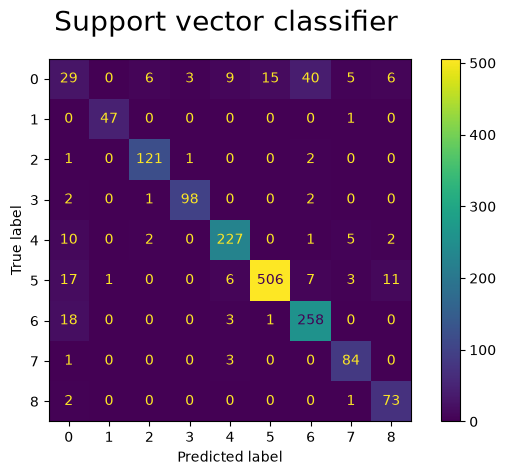

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)
print(f"Macro-F1: {macro_f1(y_test, y_pred_best)}")

cm_best = confusion_matrix(y_test, y_pred_best)
cmd_best = ConfusionMatrixDisplay(cm_best)
cmd_best.plot()
plt.suptitle(best_name, fontsize=20)
plt.tight_layout()
plt.show()

### Ensemble classifier

In [18]:
from sklearn.ensemble import VotingClassifier

vc = VotingClassifier(
    [
        ("dt", grid_search_dt.best_estimator_),
        ("mlp", grid_search_mlp.best_estimator_),
        ("svc", grid_search_svc.best_estimator_)
    ],
    voting="hard",
    weights=[1, 1, 1.1], # I give SVC a higher weight so that it wins 3-way ties.
    n_jobs=-1,
    verbose=True
)

vc.fit(X_train, y_train)

[Voting] ...................... (3 of 3) Processing svc, total=   5.9s
[Voting] ...................... (2 of 3) Processing mlp, total=  11.2s
[Voting] ....................... (1 of 3) Processing dt, total=  14.2s


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt', ...), ('mlp', ...), ...]"
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 1, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",True
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](9,)","[0,1,2,...,7,8,9]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[DecisionTreeC...ndom_state=67), Pipeline(step...m_state=67))]), Pipeline(step...amma=0.004))])]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,1024


Macro-F1: 0.8499353049417784


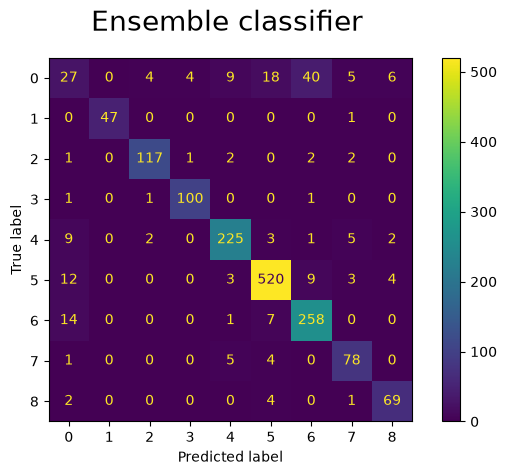

In [41]:
# Ensemble
y_pred_vc = vc.predict(X_test)
print(f"Macro-F1: {macro_f1(y_test, y_pred_vc)}")

cm_vc = confusion_matrix(y_test, y_pred_vc)
cmd_vc = ConfusionMatrixDisplay(cm_vc)
cmd_vc.plot()
plt.suptitle("Ensemble classifier", fontsize=20)
plt.tight_layout()
plt.show()

### Comparing best model and ensemble model

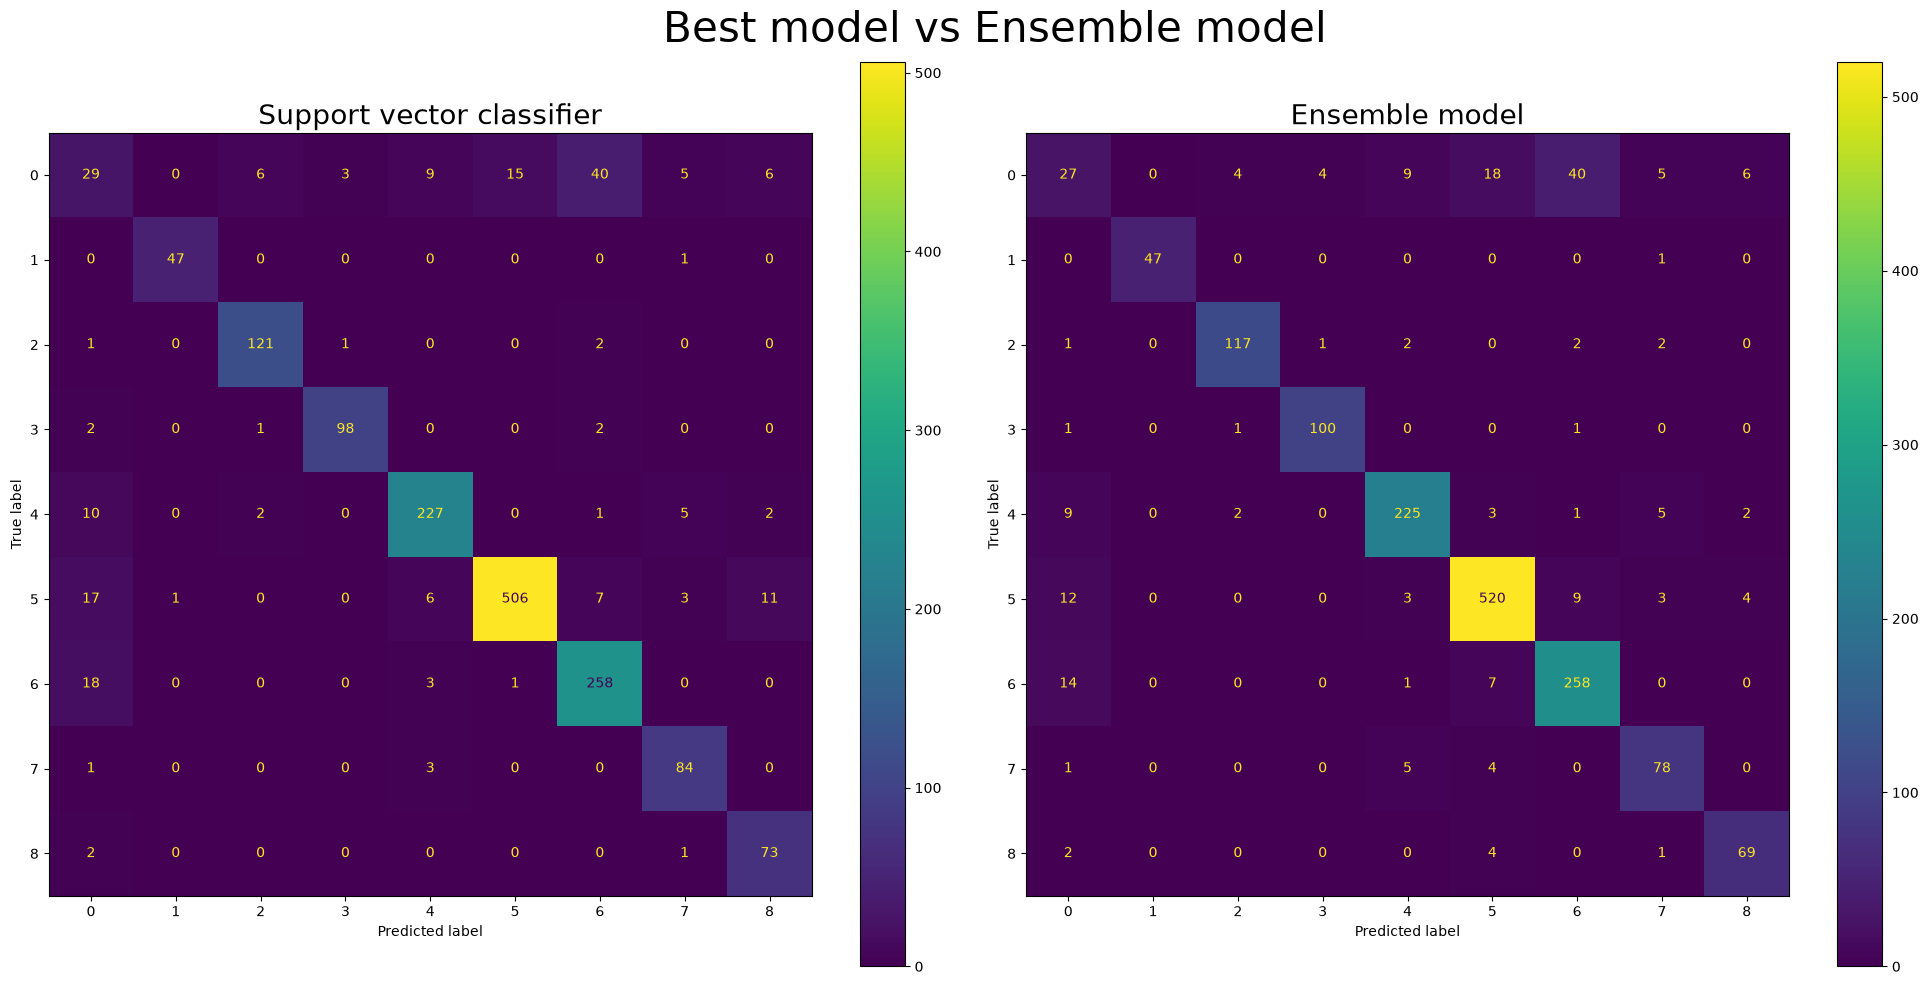

In [43]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

cmd_best.plot(ax=ax1)
cmd_vc.plot(ax=ax2)
ax1.set_title(best_name, fontsize=20)
ax2.set_title("Ensemble model", fontsize=20)
plt.suptitle("Best model vs Ensemble model", fontsize=30)

plt.tight_layout()
plt.show()